# **Лабораторная работа 1. Асимптотика. Бинарный поиск. Линейные алгоритмы.**

Емцова Анна Сергеевна

# 1. Изучите ```perf_counter()``` и ```perf_counter_ns()```.

`perf_counter()` и `perf_counter_ns()` — это функции из модуля `time`, предоставляющие **доступ к высокоточным таймерам**.

Посмотрите на пример измерения времени работы какого-то фрагмента кода.

In [1]:
import time

# perf_counter() — возвращает время в СЕКУНДАХ (float)
start = time.perf_counter()
s = sum(range(100000))  # некоторый измеряемый фрагмент кода
end = time.perf_counter()
print(end - start)

# perf_counter_ns() — возвращает время в НАНОСЕКУНДАХ (int)
start_ns = time.perf_counter_ns()
s = sum(range(100000)) # некоторый измеряемый фрагмент кода
end_ns = time.perf_counter_ns()
print(end_ns - start_ns)

0.0011334160000000537
1136750


# 2. Как проводить измерение времени работы алгоритма и глубины рекурсии (для рекурсивных алгоритмов)

Напишем простую рекурсивную функцию для подсчета факториала числа. И на её примере посмотрим как измерять время работы алгоритма, а также глубину рекурсии.

In [2]:
import sys
sys.setrecursionlimit(10000)
def factorial(n):
    if n <= 1:
        return 1
    return n * factorial(n-1)

Проведем анализ сложности этой функции.

Для нее верно следующее рекуррентное соотношение
```
T(n) = T(n-1) + O(1)
T(1) = O(1)
```

Выполним процесс развертывания рекурсивной функции.

```
T(n) = T(n-1) + 1
T(n) = [T(n-2) + 1] + 1 = T(n-2) + 2
T(n) = [T(n-3) + 1] + 2 = T(n-3) + 3
```

**на шаге k получим**
```
T(n) = T(n-k) + k
```
При k = n-1 достигнем базового случая (доходим до T(1)):

```
T(n) = T(1) + (n-1)
T(n) = 1 + (n-1)
T(n) = n
```

**Временная сложность:** **O(n)** — линейная

## Анализ времени (через функцию измерения времени)

Напишем функцию, которая измеряет время работы этой функции на разных размерах входных данных, чтобы на реальных замерах убедиться, что время работы функции линейное.

In [3]:
def measure_factorial_time(n, repeats=10): # repeats число повторов для одной сессии измерений
    times = []

    for _ in range(repeats):
        start = time.perf_counter_ns()
        result = factorial(n)
        end = time.perf_counter_ns()
        times.append(end - start)

    # убираем выбросы (минимальное и максимальное время) и усредняем
    if repeats > 2:
        times.sort()
        times = times[1:-1]

    avg_time = sum(times) / len(times)
    return avg_time, result

times_ns = [] # тут будет время работы
init_n = list(range(100, 1001, 50)) # тут будут исходные размеры входных данных

for n in init_n:
    time_ns, _ = measure_factorial_time(n, repeats=10)
    times_ns.append(time_ns)

Теперь визуализируем результаты, чтобы на графике убедиться в корректности наших выводов о времени работы функции.

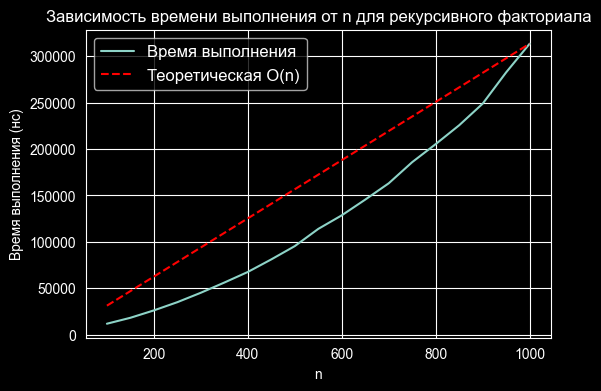

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.plot(init_n, times_ns, label='Время выполнения')


import numpy as np
theoretical_log = [n for n in init_n]
scale_factor = max(times_ns) / max(theoretical_log)
theoretical_time = [t * scale_factor for t in theoretical_log]
plt.plot(init_n, theoretical_time, 'r--', label='Теоретическая O(n)')


plt.xlabel('n')
plt.ylabel('Время выполнения (нс)')
plt.title('Зависимость времени выполнения от n для рекурсивного факториала')
plt.legend(fontsize=12, loc='upper left')

Измерение времени зависит от множества факторов: загрузки процессора, фоновых процессов, и даже (внезапно!) температуры CPU и т.д. Сегодня алгоритм выполняется 1.2 мс, завтра -- 1.5 мс, и непонятно, что изменилось. Поэтому используют еще один подход -- измеряют количество операций. Ведь количество операций -- детерминировано: для факториала 5 всегда будет 5 умножений.

## Анализ времени (через измерение числа операций)

Перепишем функцию факториала, чтобы можно было измерить число операций. К сожалению, придется немного испортить нашу функцию.

In [5]:
def factorial(n):
    def _fact(n):
        nonlocal operations
        operations += 1  # каждая проверка условия - операция
        if n <= 1:
            return 1
        operations += 3
        # умножение, вычитание и вызов функции это еще три операции
        return n * _fact(n-1)

    operations = 0
    result = _fact(n)
    return result, operations

In [6]:
def count_factorial_operations(n, repeats=10):
    times = []
    result = None

    for _ in range(repeats):
        result, ops = factorial(n)

    return result, ops

init_n = list(range(100, 1001, 50))
times_ns = []
operations_list = []

for n in init_n:
    _, ops = count_factorial_operations(n, repeats=10)
    operations_list.append(ops)

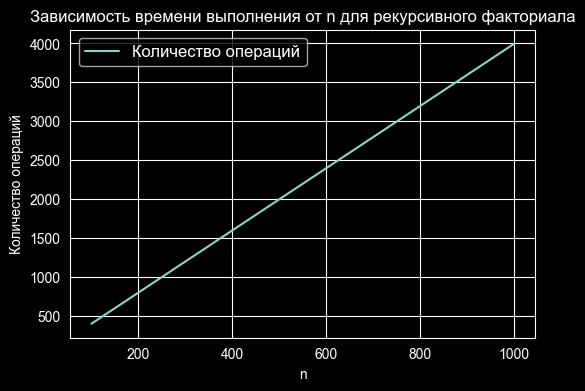

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.plot(init_n, operations_list, label='Количество операций')

plt.xlabel('n')
plt.ylabel('Количество операций')
plt.title('Зависимость времени выполнения от n для рекурсивного факториала')
plt.legend(fontsize=12, loc='upper left')

Обратите внимание, на графике нет выбросов и зависимость более четкая. Также не нужно выполнять несколько повторов.

## Анализ глубины рекурсии

Перепишем функцию, чтобы можно было измерить максимальную глубину рекурсии

In [8]:
def factorial(n):
    def _fact(n, depth):
        nonlocal max_depth
        max_depth = max(max_depth, depth)

        if n <= 1:
            return 1

        return n * _fact(n-1, depth + 1)

    max_depth = 0
    result = _fact(n, 1)  # начинаем с глубины 1
    return result, max_depth

init_n = list(range(100, 1001, 50))
depth_list = []

for n in init_n:
    _, depth = factorial(n)
    depth_list.append(depth)

Фактически, в данном примере, для нас глубина рекурсии показывает количество используемой памяти. Видим, что максимальная глубина рекурсии линейно зависит от размера входных данных. Учитывая, что на каждом вызове у нас создается/копируется константное количество переменных -- память используемая (то есть пространтсвенная сложность) **O(N)**

# Задание 1 (4 балла). Левосторонний бинарный поиск

**Левосторонний бинарный поиск (leftmost binary search)** -- ищет первое вхождение элемента в отсортированном массиве. Если элемент встречается несколько раз, возвращает индекс самого левого (минимального) вхождения.

### Предварительная подготовка

1. Реализовать наивную рекурсивную функцию левостороннего бинарного поиска в отсортированном массиве.
2. Реализовать наивную итеративную функцию левостороннего бинарного поиска в отсортированном массиве.
3.  Вывести асимптотическую сложность алгоритма **методом развертывания рекуррентного соотношения** (записать рекуррентное соотношение для T(n), выполнить пошаговое развертывание, получить формулу и итоговую асимптотику), для обоих реализаций.

In [9]:
#Левосторонний бинарный поиск - наивная рекурсивная функция
def binary_search_left_rec(arr, target, l, r):
    if l >= r:
        return l
    mid = (l+r)//2
    if arr[mid] < target:
        return binary_search_left_rec(arr, target, mid + 1, r)
    else:
        return binary_search_left_rec(arr, target, l, mid)


**Асимпотическая сложность алгоритма методом развертывания рекурретного соотношения:**
- Рекурретное соотношение:
```
T(n) = T(n/2) + 1
```
- Развертывание рекурретного соотношения:
```
T(n/2) = T(n/4) + 1
T(n/4) = T(n/8) + 1
...
```
На втором шаге:
```
=> T(n) = (T(n/4) + 1) + 1 = T(n/4) + 2
```
На третьем шаге:
```
=> T(n) = (T(n/8) + 1) + 2 = T(n/8) + 3
```

На шаге k получим:
```
=> T(n) = T(n/2^k) + k
```

- На k = log2(n) достигаем базового случая (T(1)):
T(n) = T(1) + log2(n)
T(n) = log2(n) + 1

- Временная сложность:
```
O(log(n))
```

In [10]:
#Левосторонний бинарный поиск - наивная итеративная функция
def binary_search_left_iter(arr, target):
    l = 0
    r = len(arr) - 1
    while l < r:
        mid = (l+r)//2
        if arr[mid] < target:
            l = mid + 1
        else:
            r = mid
    return l

**Асимпотическая сложность алгоритма методом развертывания рекурретного соотношения:**

- Рекурретное соотношение:
```
T(n) = T(n/2) + 1
```
- Развертывание рекурретного соотношения:
```
T(n/2) = T(n/4) + 1
T(n/4) = T(n/8) + 1
...
```
На втором шаге:
```
=> T(n) = (T(n/4) + 1) + 1 = T(n/4) + 2
```
На третьем шаге:
```
=> T(n) = (T(n/8) + 1) + 2 = T(n/8) + 3
```

На шаге k получим:
```
=> T(n) = T(n/2^k) + k
```

- На k = log2(n) достигаем базового случая (T(1)):
T(n) = T(1) + log2(n)
T(n) = log2(n) + 1

- Временная сложность:
```
O(log(n))
```

### Провести эксперименты

5. Взять для экспериментов размеры массивов от 100 до 5000 с шагом 100.
6. Сгенерировать (определить) три типа входных данных для каждого размера массива (лучший случай, средний случай, худший случай).
7. Для каждого алгоритма, каждого размера массива и каждого типа случая:
  * Подсчитать среднее время выполнения (выполнить не менее 10 повторных замеров для усреднения времени)
  * Подсчитать количество операций
  * Подсчитать максимальную глубину рекурсии

8. На одном графике отобразить зависимости среднего времени работы (лучший, средний, худший случаи разными цветами) от размера входных данных, а также теоретическую кривую O(log n) -- пунктирной линией. Для обоих алгоритмов.
9. На одном графике отобразить зависимости количества операций (лучший, средний, худший случаи разными цветами) от размера входных данных, а также теоретическую кривую O(log n) -- пунктирной линией. Для обоих алгоритмов.
10. На одном графике отобразить зависимости глубины рекурсии (лучший, средний, худший случаи разными цветами) от размера входных данных, а также теоретическую кривую O(log n) -- пунктирной линией. Для обоих алгоритмов.

**Требования к графикам:**

Сделайте
* Подписи осей
* Заголовок
* Легенду с пояснением всех линий


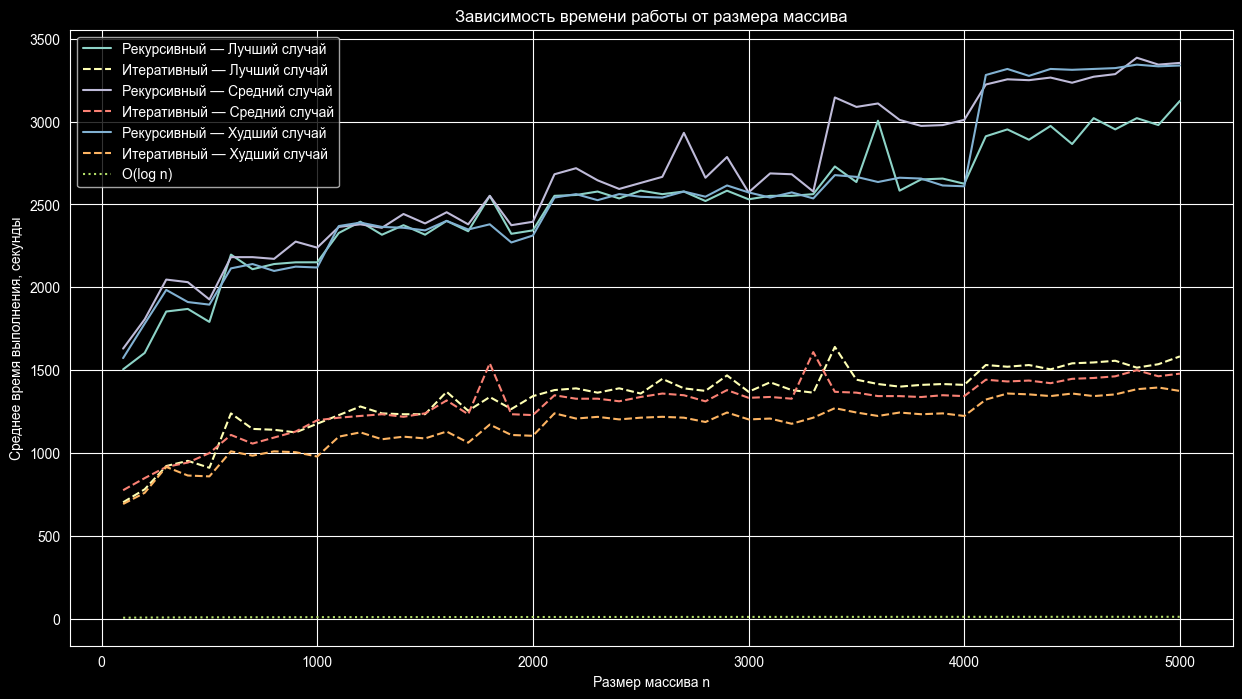

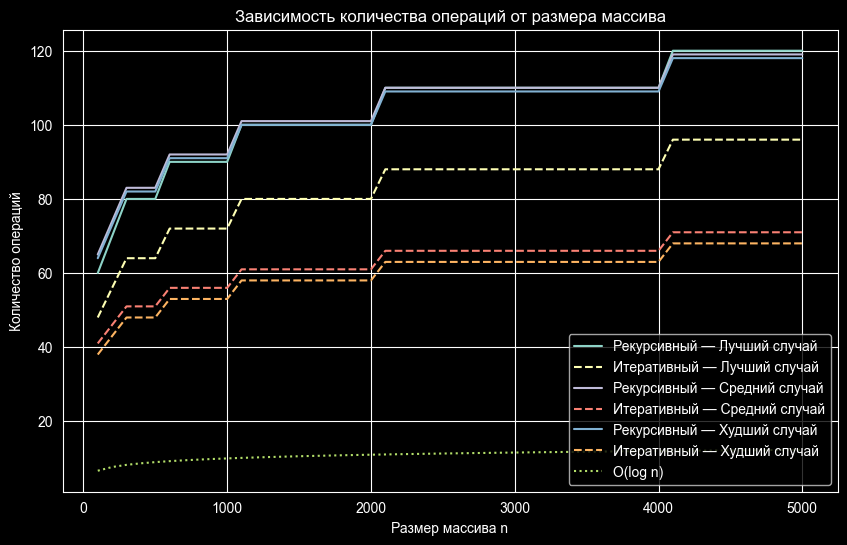

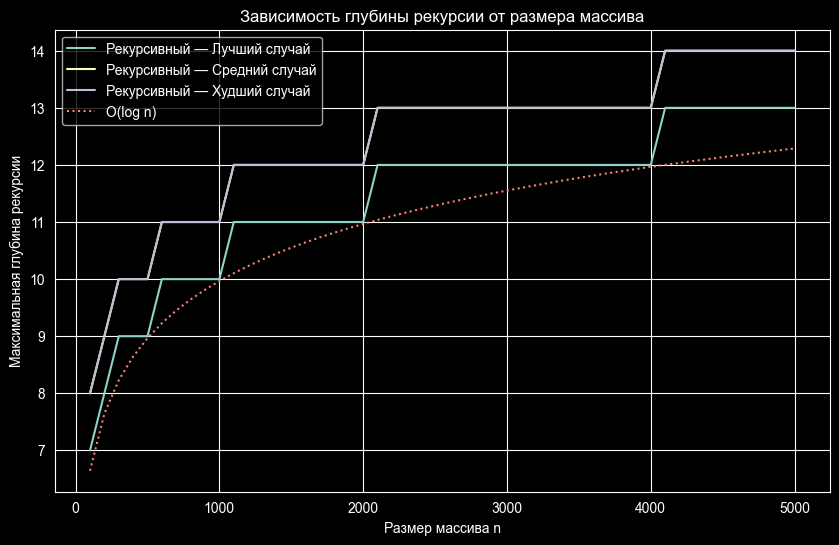

In [11]:
import time
import math

sizes = list(range(100, 5001, 100))


def generate_array(n):
    return list(range(n))


# -----------------------------
# Левосторонний бинарный поиск — рекурсивный
# -----------------------------
def binary_search_left_rec(arr, target, l, r, depth=1):

    operations = 1
    if l >= r:                                                            # сравнение (l >= r) - 1 операция
        return l, operations, depth

    mid = (l + r) // 2                                                    # деление, сложение, присваивание - 3 операции
    operations += 3

    if arr[mid] < target:                                                 # сравнение, обращение к памяти (arr[mid]) - 2 операции
        result, child_ops, max_depth = binary_search_left_rec(            # присваивание, вызов функции, сложение - 3 операции
            arr, target, mid + 1, r, depth + 1
        )
        operations += 5
    else:
        result, child_ops, max_depth = binary_search_left_rec(           # присваивание, вызов функции - 2 операции
            arr, target, l, mid, depth + 1
        )
        operations += 4

    operations += 1
    return result, operations + child_ops, max_depth                     # сложение - 1 операция


# -----------------------------
# Левосторонний бинарный поиск — итеративный
# -----------------------------
def binary_search_left_iter(arr, target):
    l = 0                                                                # присваивание - 1 операция
    r = len(arr) - 1                                                     # присваивание, вычитание - 2 операции
    operations = 3

    while l < r:                                                        # сравнение,  деление, сложение, присваивание - 4 операции
        mid = (l + r) // 2
        operations += 4

        if arr[mid] < target:                                           # обращение к памяти, сравнение - 2 операции
            l = mid + 1                                                 # присваивание, сложение - 2 операции
            operations += 4
        else:
            r = mid                                                    # присваивание - 1 операция
            operations += 1

    return l, operations, 0


def measure_time(func, *args, repeats=10):
    times = []

    for _ in range(repeats):
        start = time.perf_counter_ns()
        func(*args)
        end = time.perf_counter_ns()
        times.append(end - start)

    # убираем выбросы (минимальное и максимальное время) и усредняем
    if repeats > 2:
        times.sort()
        times = times[1:-1]

    avg_time = sum(times) / len(times)
    return avg_time

def get_cases(arr):
    n = len(arr)

    best = arr[(n - 1) // 2]
    average = arr[n // 4]
    worst = -1

    return {
        "Лучший случай": best,
        "Средний случай": average,
        "Худший случай": worst
    }


results = []

for n in sizes:
    arr = generate_array(n)
    cases = get_cases(arr)

    for case_name, target in cases.items():
        avg_time_rec = measure_time(
            binary_search_left_rec,
            arr, target, 0, len(arr) - 1,
            repeats=10
        )

        _, ops_rec, depth_rec = binary_search_left_rec(
            arr, target, 0, len(arr) - 1
        )

        avg_time_iter = measure_time(
            binary_search_left_iter,
            arr, target,
            repeats=10
        )

        _, ops_iter, depth_iter = binary_search_left_iter(arr, target)

        results.append({
            "n": n,
            "case": case_name,

            "time_rec": avg_time_rec,
            "ops_rec": ops_rec,
            "depth_rec": depth_rec,

            "time_iter": avg_time_iter,
            "ops_iter": ops_iter,
            "depth_iter": depth_iter
        })


def get_values(case_name, key):
    return [row[key] for row in results if row["case"] == case_name]


theory_log = [math.log2(n) for n in sizes]


# -----------------------------
# График 1: время работы
# -----------------------------
plt.figure(figsize=(15, 8))

for case in ["Лучший случай", "Средний случай", "Худший случай"]:
    plt.plot(sizes, get_values(case, "time_rec"), label=f"Рекурсивный — {case}")
    plt.plot(sizes, get_values(case, "time_iter"), linestyle="--", label=f"Итеративный — {case}")
plt.plot(sizes, theory_log, linestyle=":", label="O(log n)")

plt.xlabel("Размер массива n")
plt.ylabel("Среднее время выполнения, секунды")
plt.title("Зависимость времени работы от размера массива")
plt.legend()
plt.grid(True)
plt.grid(True)


# -----------------------------
# График 2: количество операций
# -----------------------------
plt.figure(figsize=(10, 6))

for case in ["Лучший случай", "Средний случай", "Худший случай"]:
    plt.plot(sizes, get_values(case, "ops_rec"), label=f"Рекурсивный — {case}")
    plt.plot(sizes, get_values(case, "ops_iter"), linestyle="--", label=f"Итеративный — {case}")

plt.plot(sizes, theory_log, linestyle=":", label="O(log n)")

plt.xlabel("Размер массива n")
plt.ylabel("Количество операций")
plt.title("Зависимость количества операций от размера массива")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# График 3: максимальная глубина рекурсии
# -----------------------------
plt.figure(figsize=(10, 6))

for case in ["Лучший случай", "Средний случай", "Худший случай"]:
    plt.plot(sizes, get_values(case, "depth_rec"), label=f"Рекурсивный — {case}")

plt.plot(sizes, theory_log, linestyle=":", label="O(log n)")

plt.xlabel("Размер массива n")
plt.ylabel("Максимальная глубина рекурсии")
plt.title("Зависимость глубины рекурсии от размера массива")
plt.legend()
plt.grid(True)
plt.show()

### Анализ результатов + ответы на вопросы

1. Сравните теоретическую асимптотику с экспериментальными данными. Совпадает ли форма кривых?
2. Сравнить рекурсивную и итеративную версии. Какая быстрее? Почему?
3. Сравнить рекурсивную и итеративную версии с точки зрения использования памяти (пространстенной сложности).
4. Объяснить разницу между лучшим, средним и худшим случаями. Когда какой случай наступает? Почему?
5. Почему при измерении времени работы функции на графике наблюдались выбросы? Какие способы его избежать существуют?

**Ответы:**
1. Форма кривых совпадают.
2. Итеративная версия занимает меньше времени, чем рекурсиная. Причина: рекурсивная версия медленнее, так как тратится время на вызов функции (больше 1-го раза), когда как в итеративной версии функция вызывается один раз.
3. Рекурсивная версия занимает больше памяти, чем итеративная. Причина: хранится стек вызовов рекурсивной функции в памяти, в итеративной версии в стеке хранится только один вызов функции.
4. Худший случай - таргета нет в массиве (массив равен -1), тогда алгоритм поделить массив на максимальное число раз. Средний случай - таргет есть в массиве и он находится не в середине массива (arr[len(n) // 4], тогда алгоритм поделит массив не на максимально количество раз, но и не на минимальное количество раз. Лучший случай - алгоритм сразу находит таргет (target = arr[(l - r) // 2], тогда алгоритм поделить массив один раз.
5. Выбросы возникают из-за множества факторов: температура CPU, фоновые процессы, загрузка процессора и т.д. Избежать можно так: убрать max и min значения в списке times. Вообще для сравнения сложности алгоритмов смотрят на детерменированную величину - количество операций функции, но трудоемко считать операции функции, поэтому на асимптотику смотрят.

# Задание 2 (3 балла). Модификация бинарного поиска

Представьте, что алгоритм бинарного поиска был изменен. На каждом шаге массив делится на 3 части.

**Принцип работы**
1. Массив делится на три части двумя точками: mid1 и mid2
2. Сравниваем искомый элемент с значениями в этих точках
3. В зависимости от результата, продолжаем поиск в одной из трех частей

Будем искать также, самое первое вхождение элемента.

### Предварительная подготовка

1. Реализовать такую версию бинарного поиска.
2.  Вывести асимптотическую сложность алгоритма **методом развертывания рекуррентного соотношения** (записать рекуррентное соотношение для T(n), выполнить пошаговое развертывание, получить формулу и итоговую асимптотику).

In [12]:
def ternary_search_rec(arr, target, l, r):
    if l>r:
        return -1

    mid1 = l + (r - l) // 3
    mid2 = r - (r - l) // 3

    if arr[mid1] == target:
        return mid1

    if arr[mid2] == target:
        return mid2

    if target < arr[mid1]:
        return ternary_search_rec(arr, target, l, mid1 - 1)

    elif target > arr[mid2]:
        return ternary_search_rec(arr, target, mid2 + 1, r)

    else:
        return ternary_search_rec(arr, target, mid1 + 1, mid2 - 1)


**Асимпотическая сложность алгоритма методом развертывания рекурретного соотношения:**

- Рекурретное соотношение:
```
T(n) = T(n/3) + 1
```
- Развертывание рекурретного соотношения:
```
T(n/3) = T(n/9) + 1
T(n/9) = T(n/27) + 1
...
```
На втором шаге:
```
=> T(n) = (T(n/9) + 1) + 1 = T(n/9) + 2
```
На третьем шаге:
```
=> T(n) = (T(n/27) + 1) + 2 = T(n/27) + 3
```

На шаге k получим:
```
=> T(n) = T(n/3^k) + k
```

- На k = log3(n) достигаем базового случая (T(1)):
T(n) = T(1) + log3(n)
T(n) = log3(n) + 1

- Временная сложность:
```
O(log(n))
```

### Провести эксперименты

4. Взять для экспериментов размеры массивов от 100 до 5000 с шагом 100.
5. Сгенерировать (определить) три типа входных данных для каждого размера массива (лучший случай, средний случай, худший случай).
6. Для каждого размера массива и каждого типа случая:
  * Подсчитать среднее время выполнения (выполнить не менее 10 повторных замеров для усреднения времени)
  * Подсчитать количество операций
  * Подсчитать максимальную глубину рекурсии

### Построить графики

7. На одном графике отобразить зависимости среднего времени работы (лучший, средний, худший случаи разными цветами) от размера входных данных, а также теоретическую кривую O(log n) -- пунктирной линией.
8. На одном графике отобразить зависимости количества операций (лучший, средний, худший случаи разными цветами) от размера входных данных, а также теоретическую кривую O(log n) -- пунктирной линией.
9. На одном графике отобразить зависимости глубины рекурсии (лучший, средний, худший случаи разными цветами) от размера входных данных, а также теоретическую кривую O(log n) -- пунктирной линией.

**Требования к графикам:**

Сделайте
* Подписи осей
* Заголовок
* Легенду с пояснением всех линий


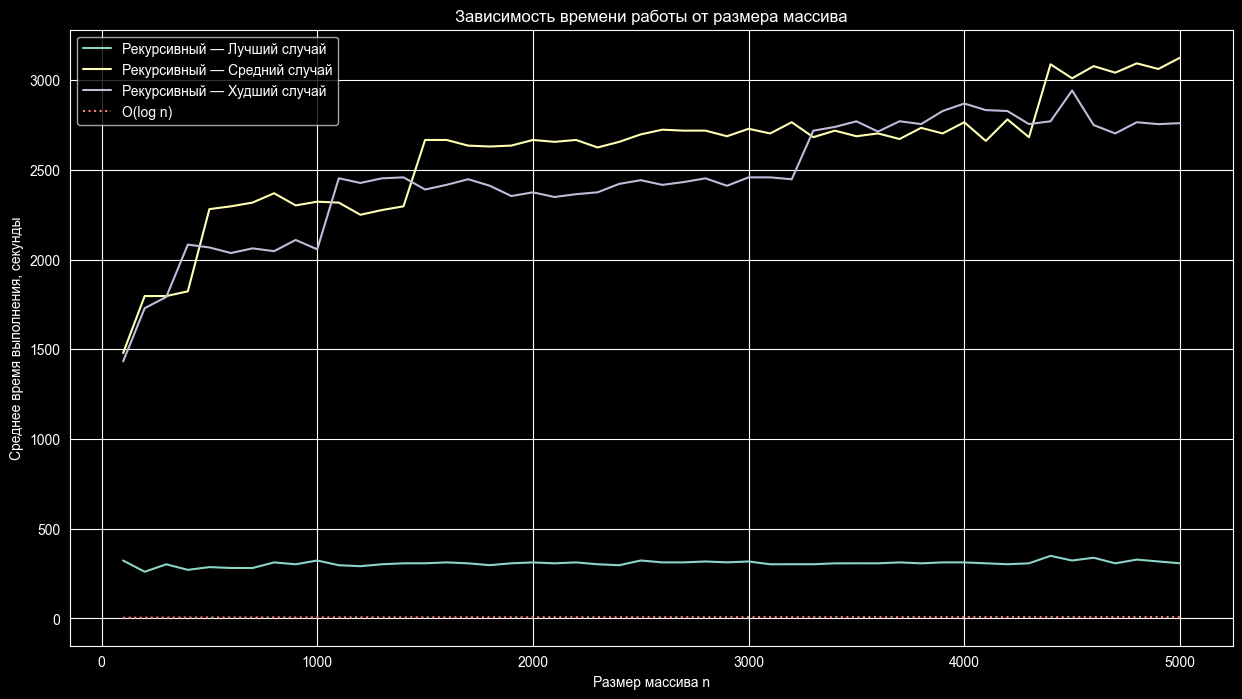

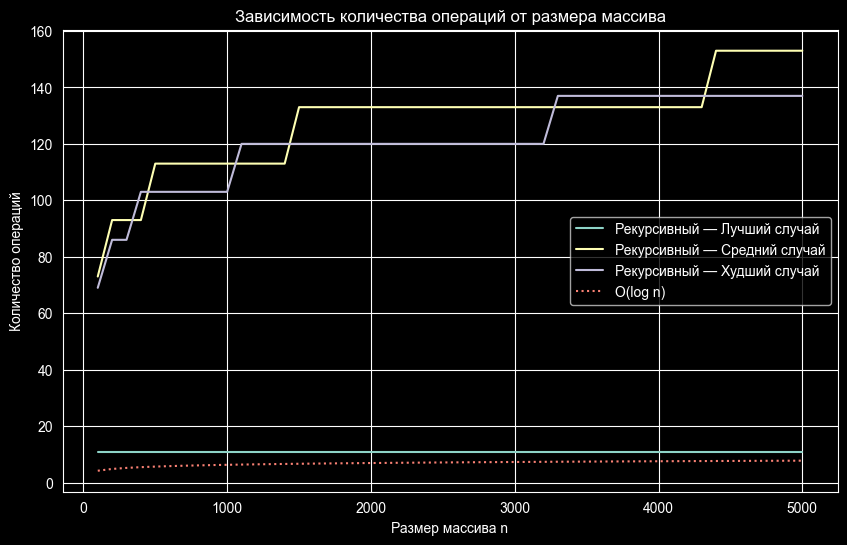

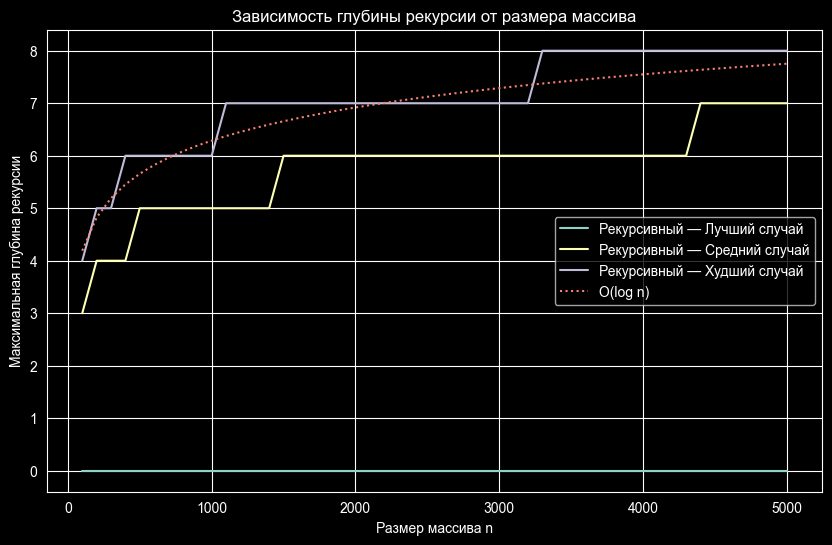

In [13]:
def ternary_search_rec(arr, target, l, r, operations = 0, depth = 0):

    operations += 1
    if l>r:                                                                   # сравнение - 1 операция
        return -1, operations, depth

    mid1 = l + (r - l) // 3                                                   # присваивание, деление, сложение, вычитание - 4 операции
    mid2 = r - (r - l) // 3                                                   # присваивание, деление, вычитание, вычитание - 4 операци
    operations += 8

    operations += 2
    if arr[mid1] == target:                                                   # обращение к памяти, сравнение - 2 операции
        return mid1, operations, depth

    operations += 2
    if arr[mid2] == target:                                                   # обращение к памяти, сравнение - 2 операции
        return mid2, operations, depth


    operations += 2
    if target < arr[mid1]:                                                   # сравнение, обращение к памяти - 2 операции
        operations += 2
        return ternary_search_rec(arr, target, l,  mid1 - 1, operations, depth + 1 )                  # вызов функции, вычитание - 2 операции


    operations += 2
    if target > arr[mid2]:                                                # сравнение, обращение к памяти - 2 операции
        operations += 2
        return ternary_search_rec(arr, target, mid2 + 1, r, operations, depth + 1)                 # вызов функции, вычитание - 2 операции

    operations += 3
    return ternary_search_rec(arr, target, mid1 + 1, mid2 - 1, operations, depth + 1)          # вызов функции, сложение, вычитание - 3 операции





def get_cases(arr):
    n = len(arr)

    best = arr[(n - 1) // 3]
    average = arr[n // 2]
    worst = -1

    return {
        "Лучший случай": best,
        "Средний случай": average,
        "Худший случай": worst
    }





results = []

for n in sizes:
    arr = generate_array(n)
    cases = get_cases(arr)

    for case_name, target in cases.items():
        avg_time_rec = measure_time(
            ternary_search_rec,
            arr, target, 0, len(arr) - 1,
            repeats=10
        )

        _, ops_rec, depth_rec = ternary_search_rec(arr, target, 0, len(arr) - 1)

        results.append({
            "n": n,
            "case": case_name,

            "time_rec": avg_time_rec,
            "ops_rec": ops_rec,
            "depth_rec": depth_rec,
        })


def get_values(case_name, key):
    return [row[key] for row in results if row["case"] == case_name]


theory_log = [math.log(n, 3) for n in sizes]



# -----------------------------
# График 1: время работы
# -----------------------------
plt.figure(figsize=(15, 8))

for case in ["Лучший случай", "Средний случай", "Худший случай"]:
    plt.plot(sizes, get_values(case, "time_rec"), label=f"Рекурсивный — {case}")
plt.plot(sizes, theory_log, linestyle=":", label="O(log n)")

plt.xlabel("Размер массива n")
plt.ylabel("Среднее время выполнения, секунды")
plt.title("Зависимость времени работы от размера массива")
plt.legend()
plt.grid(True)
plt.grid(True)
plt.show()


# -----------------------------
# График 2: количество операций
# -----------------------------
plt.figure(figsize=(10, 6))

for case in ["Лучший случай", "Средний случай", "Худший случай"]:
    plt.plot(sizes, get_values(case, "ops_rec"), label=f"Рекурсивный — {case}")

plt.plot(sizes, theory_log, linestyle=":", label="O(log n)")

plt.xlabel("Размер массива n")
plt.ylabel("Количество операций")
plt.title("Зависимость количества операций от размера массива")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# График 3: максимальная глубина рекурсии
# -----------------------------
plt.figure(figsize=(10, 6))

for case in ["Лучший случай", "Средний случай", "Худший случай"]:
    plt.plot(sizes, get_values(case, "depth_rec"), label=f"Рекурсивный — {case}")

plt.plot(sizes, theory_log, linestyle=":", label="O(log n)")

plt.xlabel("Размер массива n")
plt.ylabel("Максимальная глубина рекурсии")
plt.title("Зависимость глубины рекурсии от размера массива")
plt.legend()
plt.grid(True)
plt.show()

### Анализ результатов + ответы на вопросы

1. Сравните теоретическую асимптотику с экспериментальными данными. Совпадает ли форма кривых?
2. Сравнить классический алгоритм и алгоритм с делением на три части. Какой лучше? Почему?
3. Объяснить разницу между лучшим, средним и худшим случаями. Когда какой случай наступает? Почему?
4. Почему при измерении времени работы функции на графике наблюдались выбросы? Какие способы его избежать существуют?

**Ответы:**
1. Формы кривых совпадают.
2. Экспериментально по времени и глубине лучше алгоритм с делением на 3 части (время - недерменированная величина и зависит от многих факторов, а вторая глубина меньше, так как быстрее режется массив). По количеству операций лучше классический бинарный поиск (меньше сравнений, меньше вызовов функции).  => Классический бинарный лучше, если сравнивать по кол-ву операций.
3. Худший случай (-1) - таргета нет в массиве (алгоритма проходится по всему массиву), лучший случай ((n - 1) // 3) - таргет нашли сразу при сравнении с mid1 и mid2 (глубина рекурсии 0), средний случай (n // 4) - таргет существует в массиве, но он находится не на первом уровне глубины рекурсии.
4. Выбросы происходили из-за многих факторов: температура CPU, фоновые процессы, загрузка процессора и тд. Можно избежать следующим образом: min и max время убрать из списка times. Можно также рассматривать время времени выполнения алгоритма такую детерменированную величину как кол-во операций.

# Задание 3 (3 балла). Быстрое возведение в степень

В этом задании предстоит возвести число x в степень n, где n -- целое неотрицательное число.

## Предварительная подготовка

1. Реализовать простое наивное возведение в степень.
2. Реализовать быстрое возведение в степень.
3.  Вывести асимптотическую сложность алгоритма **методом развертывания рекуррентного соотношения** (записать рекуррентное соотношение для T(n), выполнить пошаговое развертывание, получить формулу и итоговую асимптотику). Для обоих методов.


In [14]:
def exponentiation_naive(x, n):
    if n == 0:
        return 1

    return x * exponentiation_naive(x, n - 1)


Проведем анализ сложности этой функции.

Для нее верно следующее рекуррентное соотношение
```
T(n) = T(n - 1) + O(1)
T(0) = O(1)
```

Выполним процесс развертывания рекурсивной функции.

```
T(n) = T(n - 1) + 1
T(n) = [T (n - 2) + 1] + 1 = T(n - 2) + 2
T(n) = [T(n - 3) + 1] + 3 = T(n - 3) + 3
```

**на шаге k получим**
```
T(n) = T(n - k) + k
```
При k = n достигнем базового случая (доходим до T(0)):

```
T(n) = T(0) + T(n)
T(n) = n
```

**Временная сложность:** **O(n)** — линейная

In [15]:
def exponentiation_fast(x, n):
    if n == 0:
        return 1

    if n % 2 == 0:
        half = exponentiation_fast(x, n // 2)
        return half * half
    else:
        return x * exponentiation_fast(x, n - 1)

Проведем анализ сложности этой функции.

Для нее верно следующее рекуррентное соотношение
```
T(n) = T(n // 2) + O(1)
T(1) = O(1)
```

Выполним процесс развертывания рекурсивной функции.

```
T(n) = T(n // 2) + 1
T(n) = [T (n // 4) + 1] + 1 = T(n // 4) + 2
T(n) = [T(n // 8) + 1] + 2 = T(n // 8) + 3
```

**на шаге k получим**
```
T(n) = T(n // 2^k) + k
```
При k = log2n достигнем базового случая (доходим до T(1)):

```
T(n) = T(log2n) + T(1)
T(n) = 1 + (log2n)
```

**Временная сложность:** **O(logn)** — логарифмическая

## Провести эксперименты

5. Взять для экспериментов степени от 10 до 1000 (основание 2).
6. Для каждого размера массива и каждого алгоритма:
  * Подсчитать среднее время выполнения (выполнить не менее 10 повторных замеров для усреднения времени)
  * Подсчитать количество операций
  * Подсчитать максимальную глубину рекурсии

## Построить графики

7. На одном графике отобразить зависимости среднего времени работы от размера входных данных
8. На одном графике отобразить зависимости количества операций
9. На одном графике отобразить зависимости глубины рекурсии

**Требования к графикам:**

Сделайте
* Подписи осей
* Заголовок
* Легенду с пояснением всех линий


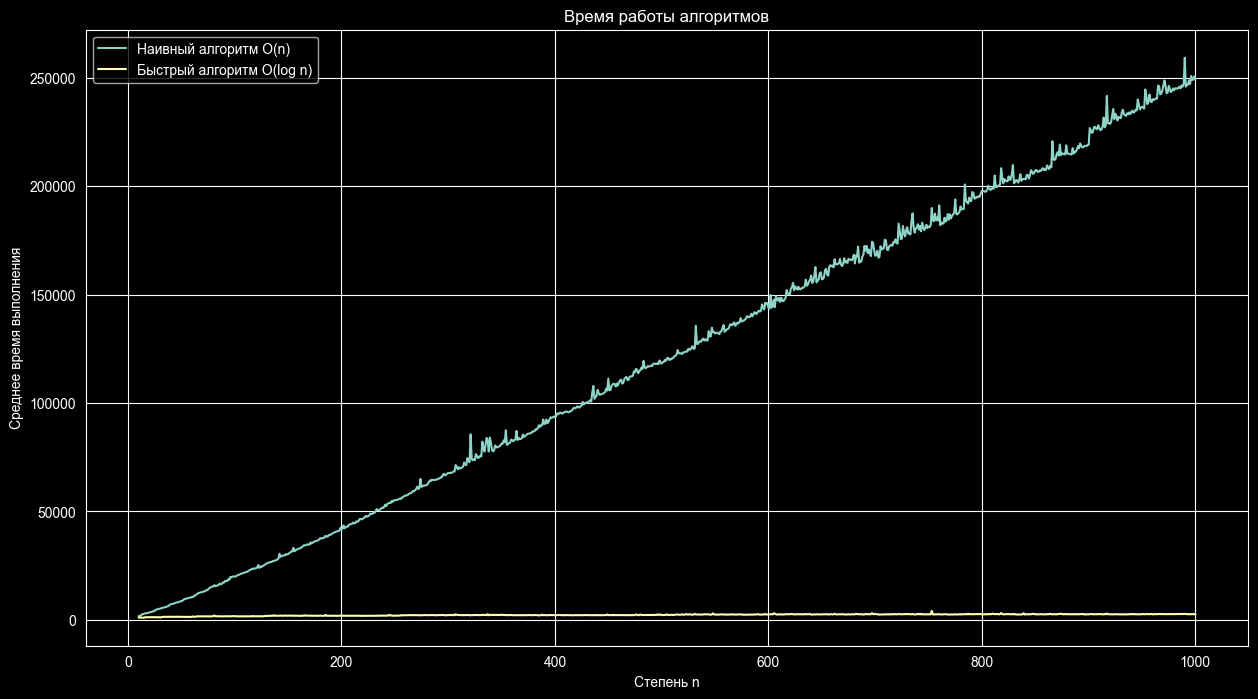

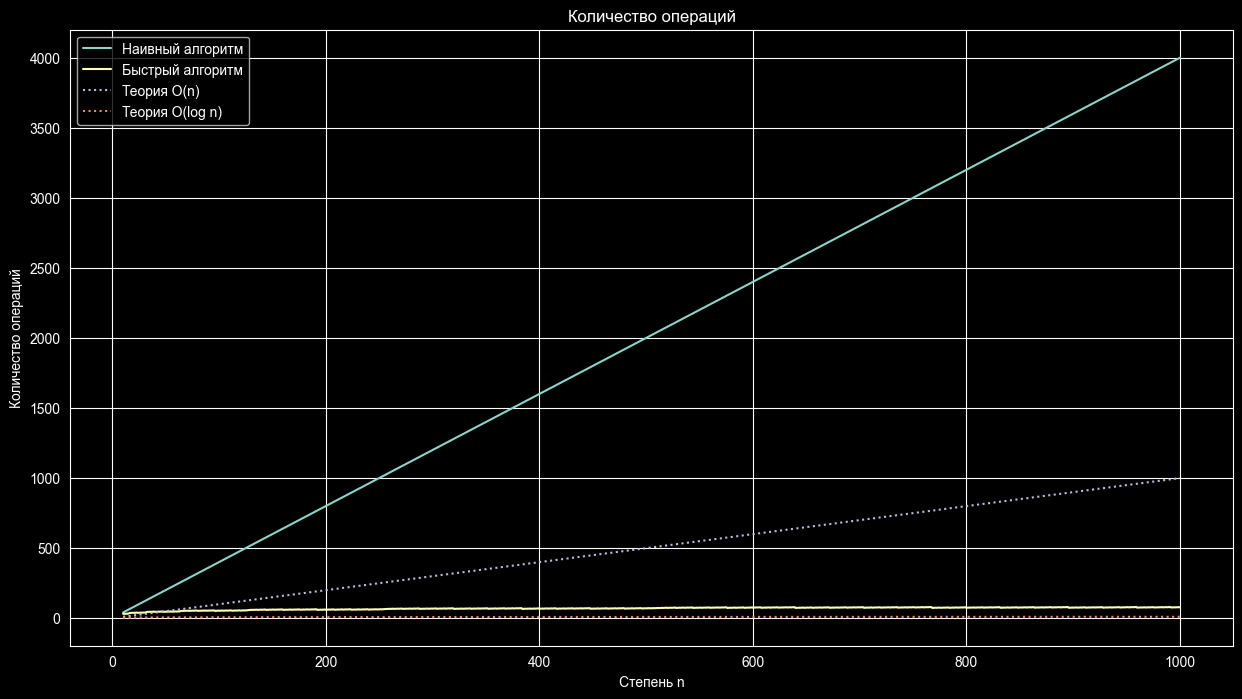

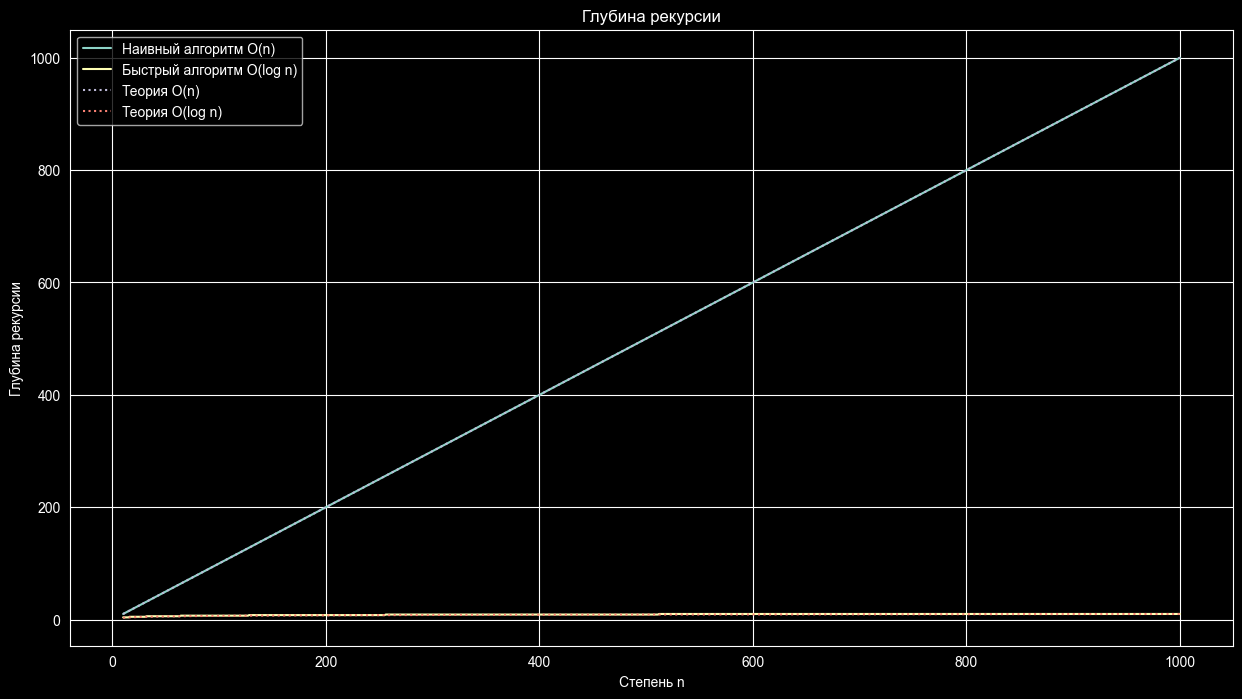

In [16]:
exponents = list(range(10, 1001))
x = 2
results = []



# -----------------------------
# Возведение в степень — наивный алгоритм
# -----------------------------
def exponentiation_naive(x, n, operations=0, depth=0):

    operations += 1  # сравнение - 1 операция
    if n == 0:
        return 1, operations, depth

    operations += 3  #вызов функции, вычитание, умножение - 3 операции

    result, operations, max_depth = exponentiation_naive(
        x,
        n - 1,
        operations,
        depth + 1
    )

    return x * result, operations, max_depth


# -----------------------------
# Возведение в степень — быстрый алгоритм
# -----------------------------
def exponentiation_fast(x, n, operations = 0, depth = 0):
    operations += 1 # сравнение - 1 операция
    if n == 0: return 1, operations, depth

    operations += 2
    if n % 2 == 0: # деление, сравнение - 2 операции
        operations += 4
        half, operations, max_depth = exponentiation_fast(x, n // 2, operations, depth + 1) # вызов функции, деление, присываивание - 3 операции
        return half * half, operations, max_depth # умножение - 1 операция

    else:
        operations += 5
        half, operations, max_depth = exponentiation_fast(x, n // 2, operations, depth + 1) # вызов функции, присваиваниеб деление - 3 операции
        return x * half * half, operations, max_depth # умножение 2 раза - 2 операции



for n in exponents:
    time_naive = measure_time(exponentiation_naive, x, n, repeats=10)
    time_fast = measure_time(exponentiation_fast, x, n, repeats=10)

    _, ops_naive, depth_naive = exponentiation_naive(x, n)
    _, ops_fast, depth_fast = exponentiation_fast(x, n)

    results.append({
        "n": n,

        "time_naive": time_naive,
        "time_fast": time_fast,

        "ops_naive": ops_naive,
        "ops_fast": ops_fast,

        "depth_naive": depth_naive,
        "depth_fast": depth_fast
    })


# -----------------------------
# Теоретические сложности
# -----------------------------
theory_linear = exponents
theory_log = [math.log2(n) for n in exponents]


def get_values(key):
    return [row[key] for row in results]


# -----------------------------
# График 1: время работы
# -----------------------------
plt.figure(figsize=(15, 8))

plt.plot(exponents,
         get_values("time_naive"),
         label="Наивный алгоритм O(n)")

plt.plot(exponents,
         get_values("time_fast"),
         label="Быстрый алгоритм O(log n)")

plt.xlabel("Степень n")
plt.ylabel("Среднее время выполнения")
plt.title("Время работы алгоритмов")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# График 2: количество операций
# -----------------------------
plt.figure(figsize=(15, 8))

plt.plot(exponents,
         get_values("ops_naive"),
         label="Наивный алгоритм")

plt.plot(exponents,
         get_values("ops_fast"),
         label="Быстрый алгоритм")

plt.plot(exponents,
         theory_linear,
         linestyle=":",
         label="Теория O(n)")

plt.plot(exponents,
         theory_log,
         linestyle=":",
         label="Теория O(log n)")

plt.xlabel("Степень n")
plt.ylabel("Количество операций")
plt.title("Количество операций")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# График 3: глубина рекурсии
# -----------------------------
plt.figure(figsize=(15, 8))

plt.plot(exponents, get_values("depth_naive"), label="Наивный алгоритм O(n)")
plt.plot(exponents, get_values("depth_fast"), label="Быстрый алгоритм O(log n)")

plt.plot(exponents, theory_linear, linestyle=":", label="Теория O(n)")
plt.plot(exponents, theory_log, linestyle=":", label="Теория O(log n)")

plt.xlabel("Степень n")
plt.ylabel("Глубина рекурсии")
plt.title("Глубина рекурсии")
plt.legend()
plt.grid(True)
plt.show()


## Анализ результатов + ответы на вопросы

1. Сравните теоретическую асимптотику с экспериментальными данными. Совпадает ли форма кривых?
2. Сравнить классический алгоритм и алгоритм быстрого возведения в степень. Какой лучше? Почему?
3. Почему при измерении времени работы функции на графике начиная с определенного значения n очень сильно выросло время работы?

**Ответы:**
1. Формы кривых совпадают.
2. Алгоритм быстрого возведения в степень лучше по времени выполнения, по кол-ву операций и по глубине рекурсии. Причина: на каждом уровне рекурсии степень n делится на 2, когда как в наивном алгоритме степень уменьшается на 1 (n - 1) => так в быстром алгоритме мы быстрее доходим до базового случая, тратя меньше операций.
3. На графике нет резкого скачка времени.